In [66]:
import pandas as pd
import seaborn as sns
import numpy as np

In [67]:
df = pd.read_csv(r"C:\Machine learning Campusx\Data\Social_Network_Ads.csv")

In [68]:
df.sample(5)

,Age,EstimatedSalary,Purchased
209,46,22000,0
325,41,60000,0
250,44,39000,0
212,59,42000,0
142,35,59000,0


In [69]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1:]

In [70]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size = 0.3 , random_state = 0)

In [71]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [72]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
X_train_scaled = pd.DataFrame(X_train_scaled , columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled , columns = X_test.columns)

In [57]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

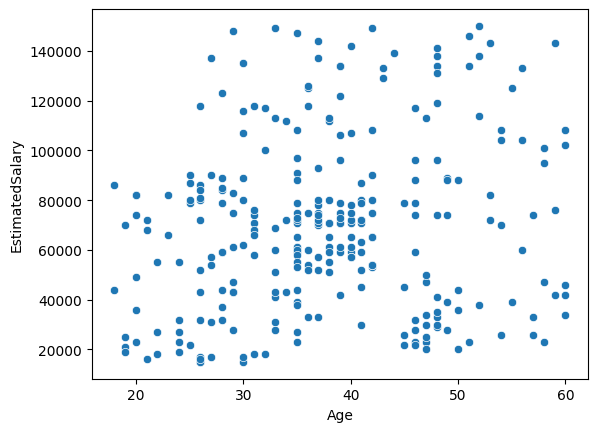

In [58]:
sns.scatterplot(x = X_train['Age'] , y = X_train['EstimatedSalary'])

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

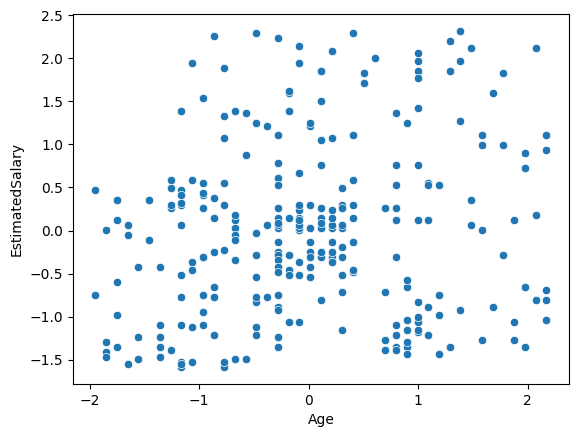

In [59]:
sns.scatterplot(x = X_train_scaled['Age'] , y = X_train_scaled['EstimatedSalary'])

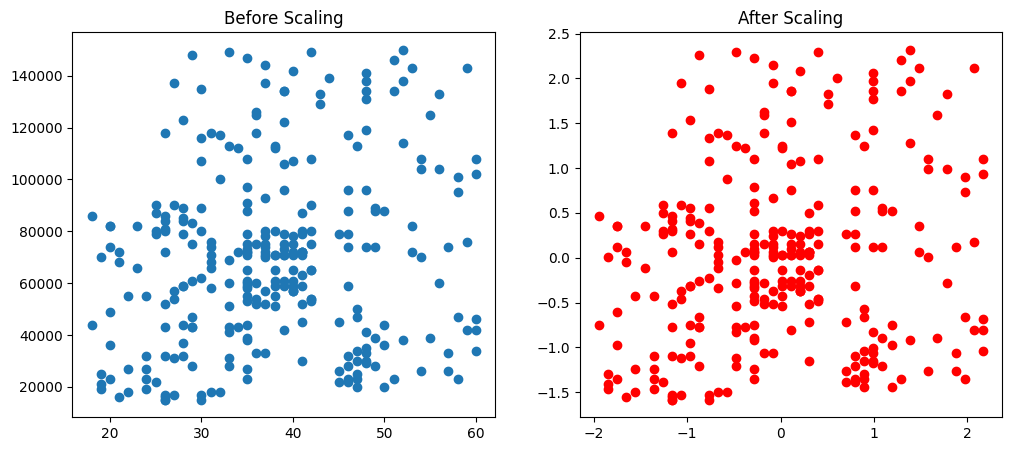

In [60]:
import matplotlib.pyplot as plt
fig , (ax1 , ax2) = plt.subplots(ncols = 2, figsize = (12,5))
ax1.scatter(X_train['Age'] , X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'] , X_train_scaled['EstimatedSalary'], color = 'red')
ax2.set_title("After Scaling")

plt.show()

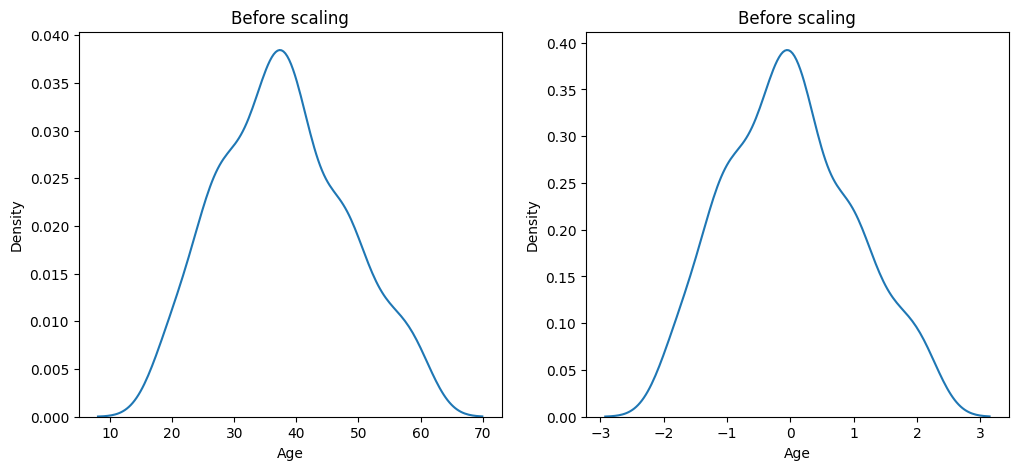

In [61]:
fig , (ax1 , ax2 ) = plt.subplots(ncols = 2, figsize = (12,5))
ax1.set_title("Before scaling")
sns.kdeplot(X_train['Age'] , ax = ax1)

ax2.set_title("Before scaling")
sns.kdeplot(X_train_scaled['Age'], ax = ax2)

plt.show()


## WHY SCALING IS IMPORTANT

In [73]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr_scaled = LogisticRegression()

lr.fit(X_train , y_train)
lr_scaled.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test) #model learnt different parameters
y_pred_scaled = lr_scaled.predict(X_test_scaled)#model learnt different parameters


c:\Users\gdeep\anaconda3\envs\100DaysML_311\Lib\site-packages\sklearn\utils\validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\gdeep\anaconda3\envs\100DaysML_311\Lib\site-packages\sklearn\utils\validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [74]:
from sklearn.metrics import accuracy_score
ac1 = accuracy_score(y_test , y_pred)
ac2 = accuracy_score(y_test, y_pred_scaled)
print(ac1,ac2)

0.875 0.8666666666666667
